# Load LIBERO dataset subset

This notebook loads a subset of the LeRobot LIBERO dataset, inspects `task_index`, and includes a quick visualization cell.

In [1]:
from pathlib import Path
import os
from libero.libero import benchmark
from libero.libero.envs import OffScreenRenderEnv
from libero.libero import get_libero_path
from lerobot.datasets.dataset_metadata import CODEBASE_VERSION, LeRobotDatasetMetadata
from huggingface_hub.constants import HF_HOME

from lerobot.datasets.io_utils import (
    embed_images,
    get_file_size_in_mb,
    hf_transform_to_torch,
    load_episodes,
    load_nested_dataset,
    write_info,
)

from lerobot.datasets.feature_utils import (
    check_delta_timestamps,
    get_delta_indices,
    get_hf_features_from_features,
    validate_episode_buffer,
    validate_frame,
)


/coc/flash7/mlin365/miniforge3/envs/lerobot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
default_cache_path = Path(HF_HOME) / "lerobot"
HF_LEROBOT_HOME = Path(
    os.getenv("HF_LEROBOT_HOME", default_cache_path)
).expanduser()

print("HF_LEROBOT_HOME:", HF_LEROBOT_HOME)


HF_LEROBOT_HOME: /coc/flash7/scratch/.cache/lerobot


In [ ]:
# features_dict = {
#     'observation.images.image': {
#         'dtype': 'image',
#         'shape': (256, 256, 3),
#         'names': ['height', 'width', 'channel'],
#         'fps': 10.0
#     },
#     'observation.images.image2': {
#         'dtype': 'image',
#         'shape': (256, 256, 3),
#         'names': ['height', 'width', 'channel'],
#         'fps': 10.0
#     },
#     'observation.state': {
#         'dtype': 'float32',
#         'shape': (8,),
#         'names': ['state'],
#         'fps': 10.0
#     },
#     'action': {
#         'dtype': 'float32',
#         'shape': (7,),
#         'names': ['actions'],
#         'fps': 10.0
#     },
#     'timestamp': {
#         'dtype': 'float32',
#         'shape': (1,),
#         'names': None,
#         'fps': 10.0
#     },
#     'frame_index': {
#         'dtype': 'int64',
#         'shape': (1,),
#         'names': None,
#         'fps': 10.0
#     },
#     'episode_index': {
#         'dtype': 'int64',
#         'shape': (1,),
#         'names': None,
#         'fps': 10.0
#     },
#     'index': {
#         'dtype': 'int64',
#         'shape': (1,),
#         'names': None,
#         'fps': 10.0
#     },
#     'task_index': {
#         'dtype': 'int64',
#         'shape': (1,),
#         'names': None,
#         'fps': 10.0
#     }
# }


In [3]:
features_dict = {
        "observation.images.image": {
            "dtype": "image",
            "shape": [
                256,
                256,
                3
            ],
            "names": [
                "height",
                "width",
                "channel"
            ],
            "fps": 10
        },
        "observation.images.wrist_image": {
            "dtype": "image",
            "shape": [
                256,
                256,
                3
            ],
            "names": [
                "height",
                "width",
                "channel"
            ],
            "fps": 10
        },
        "observation.state": {
            "dtype": "float32",
            "shape": [
                8
            ],
            "names": {
                "motors": [
                    "x",
                    "y",
                    "z",
                    "rx",
                    "ry",
                    "rz",
                    "rw",
                    "gripper"
                ]
            },
            "fps": 10
        },
        "action": {
            "dtype": "float32",
            "shape": [
                7
            ],
            "names": {
                "motors": [
                    "x",
                    "y",
                    "z",
                    "roll",
                    "pitch",
                    "yaw",
                    "gripper"
                ]
            },
            "fps": 10
        },
        "timestamp": {
            "dtype": "float32",
            "shape": [
                1
            ],
            "names": None,
            "fps": 10
        },
        "frame_index": {
            "dtype": "int64",
            "shape": [
                1
            ],
            "names": None,
            "fps": 10
        },
        "episode_index": {
            "dtype": "int64",
            "shape": [
                1
            ],
            "names": None,
            "fps": 10
        },
        "index": {
            "dtype": "int64",
            "shape": [
                1
            ],
            "names": None,
            "fps": 10
        },
        "task_index": {
            "dtype": "int64",
            "shape": [
                1
            ],
            "names": None,
            "fps": 10
        }
}

In [4]:
features = get_hf_features_from_features(features_dict)
features


{'observation.images.image': Image(mode=None, decode=True),
 'observation.images.wrist_image': Image(mode=None, decode=True),
 'observation.state': List(Value('float32'), length=8),
 'action': List(Value('float32'), length=7),
 'timestamp': List(Value('float32'), length=1),
 'frame_index': List(Value('int64'), length=1),
 'episode_index': List(Value('int64'), length=1),
 'index': List(Value('int64'), length=1),
 'task_index': List(Value('int64'), length=1)}

In [5]:
repo_id = "lerobot/libero_spatial_image"
root = HF_LEROBOT_HOME / repo_id
meta = LeRobotDatasetMetadata(
            repo_id, root, 'v3.0', force_cache_sync=False
        )
print(root)

/coc/flash7/scratch/.cache/lerobot/lerobot/libero_spatial_image


In [6]:
data_path = root / "data"
# data_path = HF_LEROBOT_HOME / "HuggingFaceVLA/libero/data"

ds = load_nested_dataset(
    data_path,
    features,
    episodes=[0, 100],
)

print("Dataset loaded!")


DatasetGenerationError: An error occurred while generating the dataset

In [7]:
from datasets import load_dataset

ds = load_dataset(path=root.as_posix())

In [8]:
ds = ds["train"]
print(ds)


Dataset({
    features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
    num_rows: 52970
})


In [10]:
task_indices = ds["task_index"]

print("First 20 task indices:")
print(task_indices[:20])
print("Unique task indices:")
print(set(task_indices))


First 20 task indices:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Unique task indices:
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [13]:
print(len(ds["task_index"]))
print(len(ds["episode_index"]))
print(set(ds["episode_index"]))

52970
52970
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 21

In [59]:
import numpy as np
from datasets import DatasetDict
# ---------------------------
# Define task mapping
# ---------------------------

# You should verify these indices once using your dataset!
OOD_OBJECT_TASK = 1   # next_to_cookie_box
OOD_SPATIAL_TASK = 9  # between_plate_and_ramekin


task_indices = np.array(ds["task_index"])
# OOD masks
mask_ood_object = task_indices == OOD_OBJECT_TASK
mask_ood_spatial = task_indices == OOD_SPATIAL_TASK

# ID mask
mask_id = ~(mask_ood_object | mask_ood_spatial)

# Convert to indices
idx_ood_object = np.where(mask_ood_object)[0]
idx_ood_spatial = np.where(mask_ood_spatial)[0]
idx_id = np.where(mask_id)[0]

# Select subsets (FAST)
val_unseen_object = ds.select(idx_ood_object)
val_unseen_spatial = ds.select(idx_ood_spatial)
id_ds = ds.select(idx_id)
id_split_data = id_ds.train_test_split(test_size=0.1, seed=42)
train = id_split_data["train"]
val_seen = id_split_data["test"]
# ---------------------------
# Final dataset dict
# ---------------------------

dataset_splits = DatasetDict({
    "train": train,
    "val_seen": val_seen,
    "val_unseen_object": val_unseen_object,
    "val_unseen_spatial": val_unseen_spatial,
})

# ---------------------------
# Debug prints
# ---------------------------

print(dataset_splits)
print("\nSizes:")
for k, v in dataset_splits.items():
    print(f"{k}: {len(v)}")

print("\nTask distribution:")
for k, v in dataset_splits.items():
    print(f"{k}: {set(v['task_index'])}")

DatasetDict({
    train: Dataset({
        features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 36558
    })
    val_seen: Dataset({
        features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 4063
    })
    val_unseen_object: Dataset({
        features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 6257
    })
    val_unseen_spatial: Dataset({
        features: ['observation.images.image', 'observation.images.wrist_image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 6092
    })
})

Sizes:
train: 36558
val_s

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

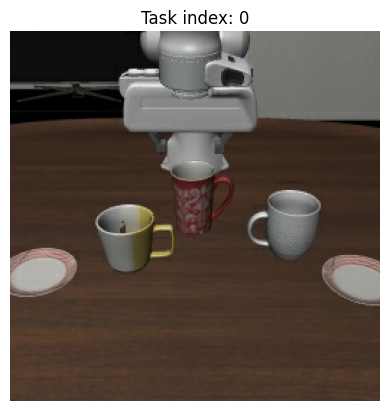

In [19]:
import matplotlib.pyplot as plt

sample = ds[0]
img = sample["observation.images.image"]

plt.imshow(img)
plt.title(f"Task index: {sample['task_index']}")
plt.axis("off")


## Optional: filter to likely LIBERO Spatial tasks

If your dataset uses task indices 0 to 9 for `libero_spatial`, you can filter like this:

In [ ]:
benchmark_dict = benchmark.get_benchmark_dict()
task_suite_name = "libero_spatial" # can also choose libero_spatial, libero_object, etc.
# task_suite_name = "libero_object" # can also choose libero_spatial, libero_object, etc.
task_suite = benchmark_dict[task_suite_name]()
print("Available tasks in the suite:")
for task in task_suite.tasks:
    print(task.name)

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Available tasks in the suite:
pick_up_the_alphabet_soup_and_place_it_in_the_basket
pick_up_the_cream_cheese_and_place_it_in_the_basket
pick_up_the_salad_dressing_and_place_it_in_the_basket
pick_up_the_bbq_sauce_and_place_it_in_the_basket
pick_up_the_ketchup_and_place_it_in_the_basket
pick_up_the_tomato_sauce_and_place_it_in_the_basket
pick_up_the_butter_and_place_it_in_the_basket
pick_up_the_milk_and_place_it_in_the_basket
pick_up_the_chocolate_pudding_and_place_it_in_the_basket
pick_up_the_orange_juice_and_place_it_in_the_basket
